# Buisness Problem

Telecommunications companies lose significant revenue when customers cancel their service. The objective of this project is to develop a machine learning model that predicts which customers are most likely to churn, enabling proactive retention strategies.

## Librairies

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

## Dataset


In [2]:
df = pd.read_excel("Telco_customer_churn[1].xlsx")

df.head()

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


## Basic Exploration

In [3]:
df.shape

df.info()

df.describe()

df.isnull().sum()

df.duplicated().sum()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

np.int64(0)

In [4]:
df["Churn Label"].value_counts(normalize=True)

Churn Label
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64

## EDA

In [5]:
df["Churn Label"].value_counts()

Churn Label
No     5174
Yes    1869
Name: count, dtype: int64

In [6]:
df["Churn Label"].value_counts(normalize=True) * 100

Churn Label
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

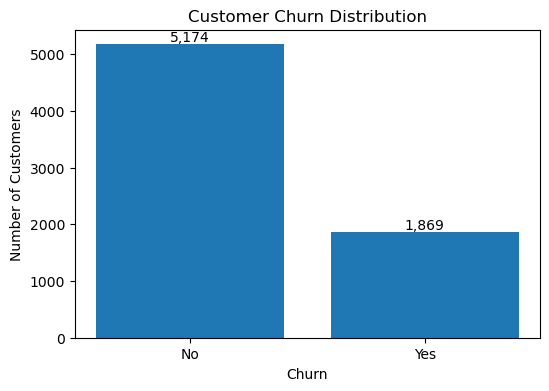

In [7]:
churn_counts = df["Churn Label"].value_counts()

plt.figure(figsize=(6,4))
plt.bar(churn_counts.index, churn_counts.values)

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")

for i, value in enumerate(churn_counts.values):
    plt.text(i, value + 50, f"{value:,}", ha='center')

plt.show()

Approximately 27% of customers have churned, indicating that customer retention is an important business challenge

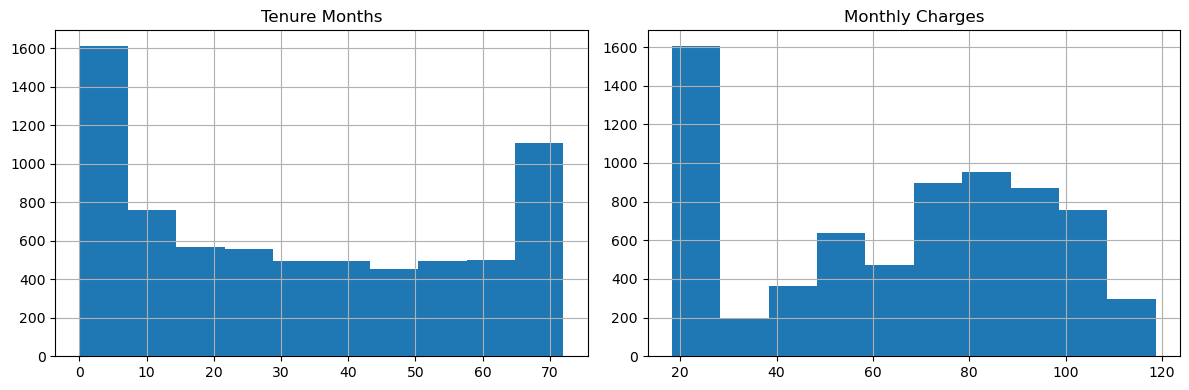

In [8]:
numerical_columns = [
    "Tenure Months",
    "Monthly Charges",
    "Total Charges"
]

df[numerical_columns].hist(figsize=(12,4))

plt.tight_layout()
plt.show()

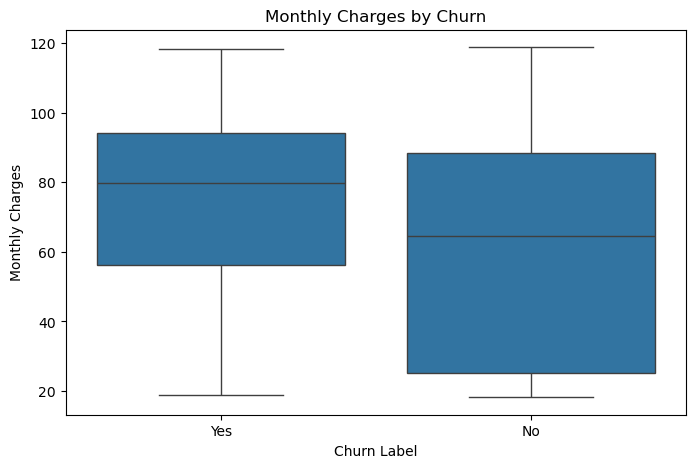

In [9]:
plt.figure(figsize=(8,5))
sns.boxplot(
    data=df,
    x="Churn Label",
    y="Monthly Charges"
)

plt.title("Monthly Charges by Churn")
plt.show()

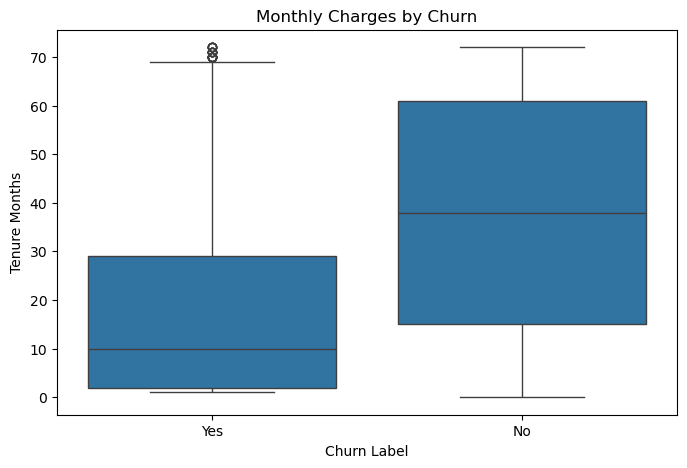

In [10]:
plt.figure(figsize=(8,5))
sns.boxplot(
    data=df,
    x="Churn Label",
    y="Tenure Months"
)

plt.title("Monthly Charges by Churn")
plt.show()

In [11]:
import matplotlib.pyplot as plt

def plot_churn_rate(df, column):
    # Calculate churn rate
    churn_rate = (
        df.groupby(column)["Churn Value"]
        .mean()
        .sort_values(ascending=False)
        * 100
    )

    plt.figure(figsize=(8,5))

    bars = plt.bar(churn_rate.index.astype(str), churn_rate.values)

    plt.title(f"Customer Churn Rate by {column}", fontsize=14)
    plt.xlabel(column)
    plt.ylabel("Churn Rate (%)")

    plt.xticks(rotation=30, ha="right")

    # Add percentage labels
    for bar in bars:
        height = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width()/2,
            height + 0.5,
            f"{height:.1f}%",
            ha="center",
            fontsize=10
        )

    plt.ylim(0, max(churn_rate.values) + 8)

    plt.tight_layout()
    plt.show()

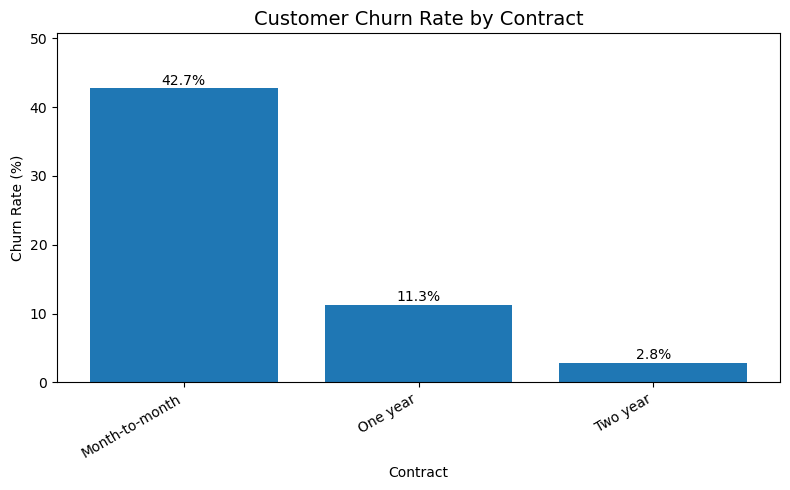

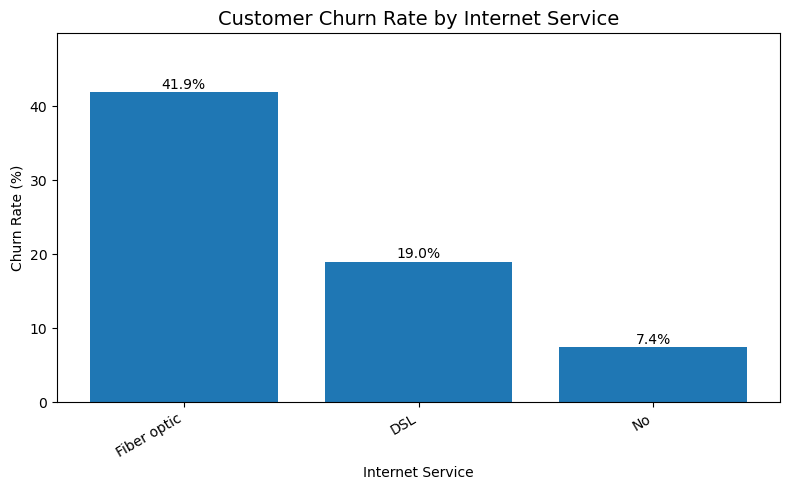

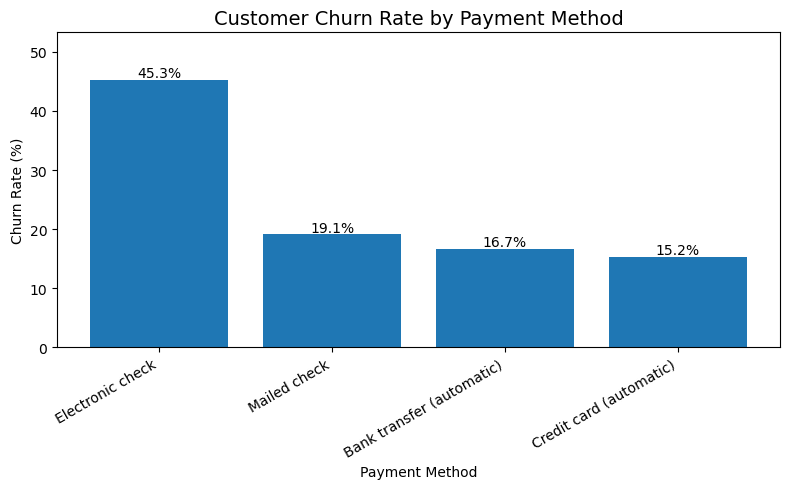

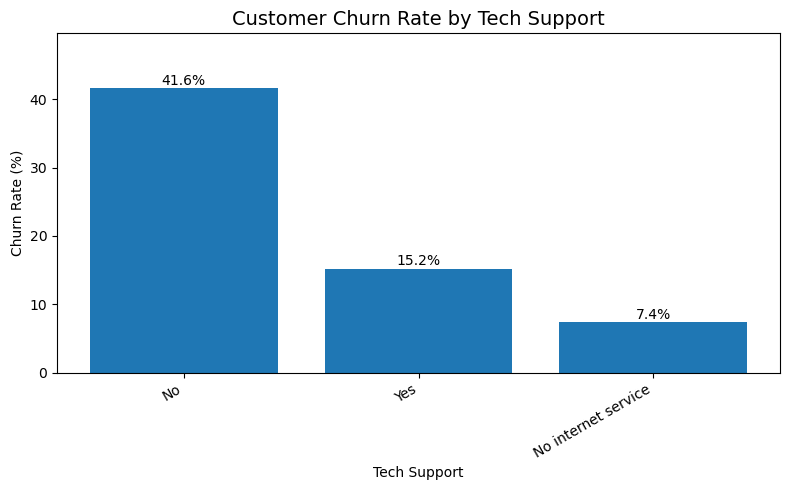

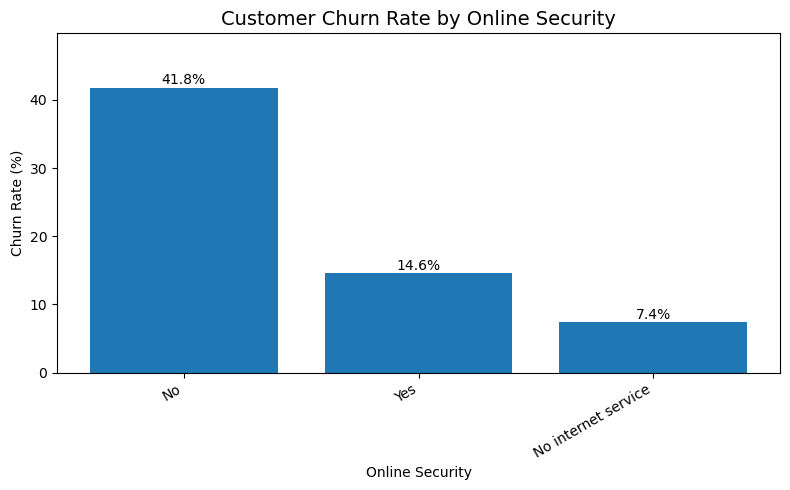

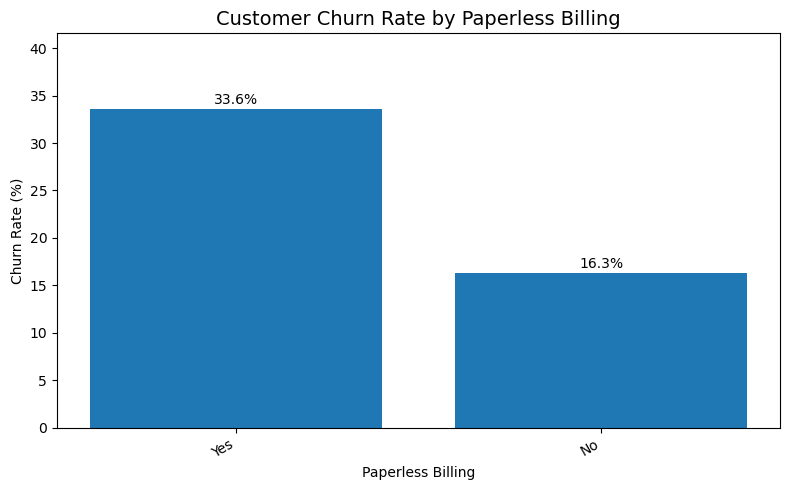

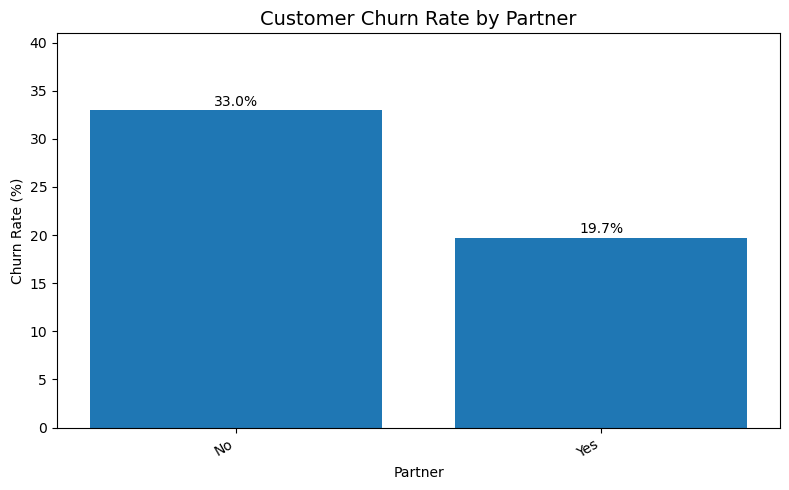

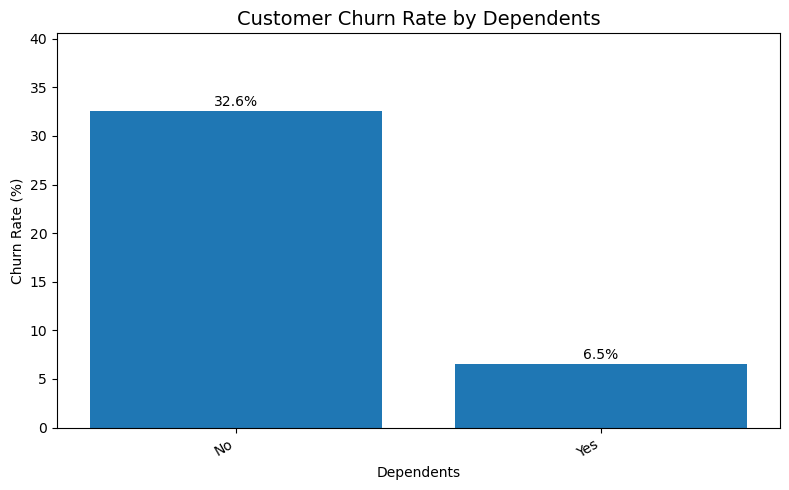

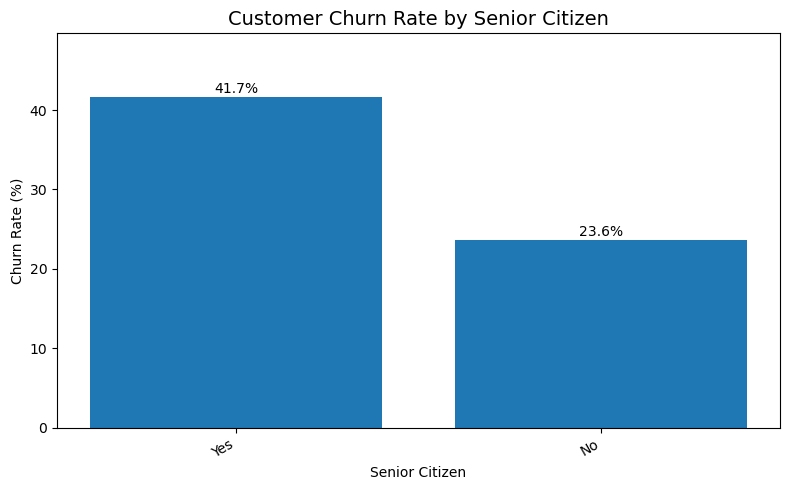

In [12]:
important_features = [
    "Contract",
    "Internet Service",
    "Payment Method",
    "Tech Support",
    "Online Security",
    "Paperless Billing",
    "Partner",
    "Dependents",
    "Senior Citizen"
]

for feature in important_features:
    plot_churn_rate(df, feature)

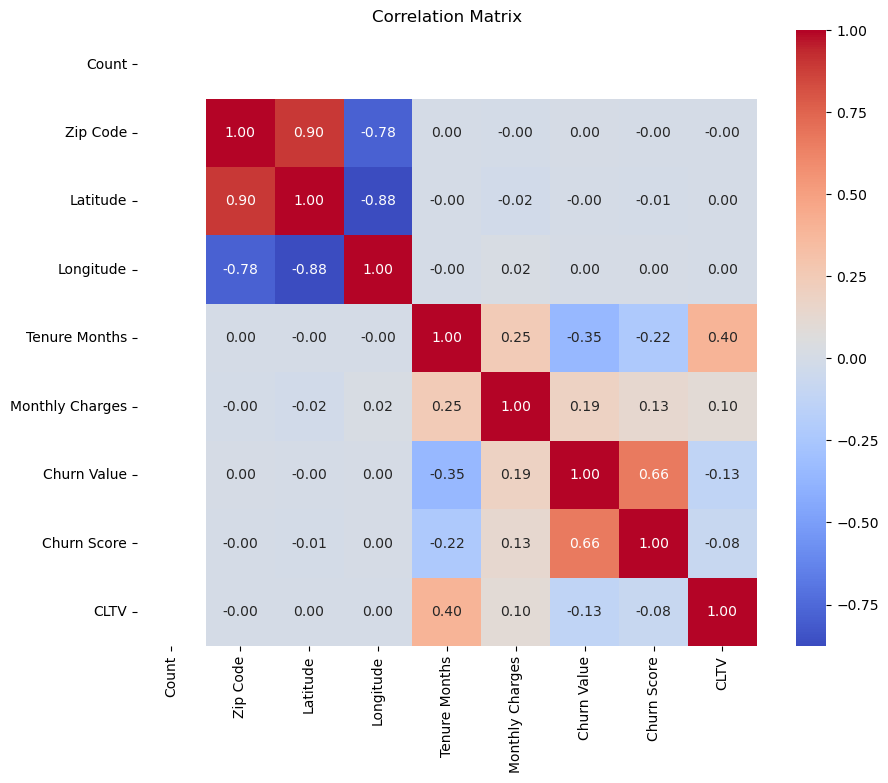

In [13]:
corr = df.select_dtypes(include="number").corr()

plt.figure(figsize=(10,8))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")
plt.show()

**Exploratory Data Analysis Conclusions**

The exploratory data analysis identified several customer characteristics associated with higher churn rates.

- Contract type emerged as the strongest predictor of customer churn, with customers on month-to-month contracts exhibiting substantially higher churn rates than those on one- or two-year contracts.
- Customers without Tech Support or Online Security experienced significantly higher churn rates, suggesting that value-added services are associated with improved customer retention.
- Fiber optic internet customers exhibited higher churn rates than DSL customers, indicating an opportunity to further investigate factors such as pricing, service quality, or customer satisfaction.
- Customers using electronic check payments demonstrated the highest churn rates, while those enrolled in automatic payment methods showed considerably greater retention.
- Customer tenure showed a strong inverse relationship with churn, with long-tenured customers being much less likely to leave than newer customers, emphasizing the importance of early retention efforts.

Overall, these findings suggest that customer churn is influenced by a combination of contract structure, service adoption, payment behavior, and customer longevity. These insights provide a strong foundation for developing predictive machine learning models and identifying high-risk customer segments for targeted retention strategies.

## Data Preparation and Preprocessing

The exploratory analysis identified several customer characteristics associated with churn. Before developing predictive models, the dataset must be prepared by removing identifiers and leakage variables, correcting data types, separating the target variable, and creating training and testing datasets.

In [14]:
model_df = df.copy()

In [15]:
model_df.shape

(7043, 33)

In [16]:
model_df["Total Charges"] = pd.to_numeric(
    model_df["Total Charges"],
    errors="coerce"
)

In [17]:
model_df["Total Charges"].dtype

dtype('float64')

In [18]:
model_df["Total Charges"].isna().sum()

np.int64(11)

In [19]:
model_df.loc[
    model_df["Total Charges"].isna(),
    ["Tenure Months", "Monthly Charges", "Total Charges"]
]

,Tenure Months,Monthly Charges,Total Charges
2234,0,52.55,NaN
2438,0,20.25,NaN
2568,0,80.85,NaN
2667,0,25.75,NaN
2856,0,56.05,NaN
4331,0,19.85,NaN
4687,0,25.35,NaN
5104,0,20.00,NaN
5719,0,19.70,NaN
6772,0,73.35,NaN


In [20]:
model_df["Total Charges"] = model_df["Total Charges"].fillna(0)

In [21]:
model_df["Total Charges"].isna().sum()

np.int64(0)

In [22]:
columns_to_drop = [
    # Identifier
    "CustomerID",

    # Constant or redundant columns
    "Count",
    "Country",
    "State",

    # High-cardinality geographic fields
    "City",
    "Zip Code",
    "Lat Long",
    "Latitude",
    "Longitude",

    # Duplicate representation of the target
    "Churn Label",

    # Leakage variables
    "Churn Score",
    "Churn Reason",

    # Excluded from baseline model
    "CLTV"
]

model_df = model_df.drop(columns=columns_to_drop)

In [23]:
model_df.columns.tolist()

['Gender',
 'Senior Citizen',
 'Partner',
 'Dependents',
 'Tenure Months',
 'Phone Service',
 'Multiple Lines',
 'Internet Service',
 'Online Security',
 'Online Backup',
 'Device Protection',
 'Tech Support',
 'Streaming TV',
 'Streaming Movies',
 'Contract',
 'Paperless Billing',
 'Payment Method',
 'Monthly Charges',
 'Total Charges',
 'Churn Value']

In [24]:
X = model_df.drop(columns="Churn Value")
y = model_df["Churn Value"]

In [25]:
print("Feature matrix:", X.shape)
print("Target vector:", y.shape)

Feature matrix: (7043, 19)
Target vector: (7043,)


In [26]:
y.value_counts(normalize=True).mul(100).round(1)

Churn Value
0    73.5
1    26.5
Name: proportion, dtype: float64

In [27]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [28]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (5634, 19)
X_test: (1409, 19)
y_train: (5634,)
y_test: (1409,)


In [29]:
print("Training churn rate:", y_train.mean().round(3))
print("Testing churn rate:", y_test.mean().round(3))

Training churn rate: 0.265
Testing churn rate: 0.265


In [30]:
numerical_features = X_train.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X_train.select_dtypes(
    include=["object"]
).columns.tolist()

In [31]:
print("Numerical features:")
print(numerical_features)

print("\nCategorical features:")
print(categorical_features)

Numerical features:
['Tenure Months', 'Monthly Charges', 'Total Charges']

Categorical features:
['Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Phone Service', 'Multiple Lines', 'Internet Service', 'Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method']


In [32]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

In [33]:
numerical_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

In [34]:
categorical_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore",
                drop="first"
            )
        )
    ]
)

In [35]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            numerical_pipeline,
            numerical_features
        ),
        (
            "categorical",
            categorical_pipeline,
            categorical_features
        )
    ]
)

### Preprocessing Summary

The following preparation steps were completed:

- Converted Total Charges from an object column to a numeric variable.
- Replaced blank total-charge values with zero for newly enrolled customers.
- Removed customer identifiers, constant fields, high-cardinality geographic variables, and target-leakage columns.
- Selected Churn Value as the binary target variable.
- Divided the data into stratified training and testing sets.
- Created preprocessing pipelines to standardize numerical variables and one-hot encode categorical variables.
- Ensured that preprocessing will be fitted exclusively on the training data to prevent data leakage.

## Logistic Regression

In [36]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)

In [37]:
log_reg = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(random_state=42))
    ]
)

In [38]:
log_reg.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numeric',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Tenure Months',
                                                   'Monthly Charges',
                                                   'Total Charges']),
                                                 ('categorical',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore'))]),
                                                  ['Gender', 'Senior Citizen',
                                                   'Partner', 'Dependents',
                                                   'Phone Service',
                                                   'Multiple Lines',
                                                   'Internet Service',
                                                   'Online Security',
                                                   'Online Backup',
                                                   'Device Protection',
                                                   'Tech Support',
                                                   'Streaming TV',
                                                   'Streaming Movies',
                                                   'Contract',
                                                   'Paperless Billing',
                                                   'Payment Method'])])),
                ('classifier', LogisticRegression(random_state=42))])

In [39]:
y_pred = log_reg.predict(X_test)

y_prob = log_reg.predict_proba(X_test)[:,1]

In [40]:
print("Accuracy :", round(accuracy_score(y_test, y_pred),3))
print("Precision:", round(precision_score(y_test, y_pred),3))
print("Recall   :", round(recall_score(y_test, y_pred),3))
print("F1 Score :", round(f1_score(y_test, y_pred),3))
print("ROC AUC  :", round(roc_auc_score(y_test, y_prob),3))

Accuracy : 0.802
Precision: 0.643
Recall   : 0.572
F1 Score : 0.605
ROC AUC  : 0.849


In [41]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1035
           1       0.64      0.57      0.61       374

    accuracy                           0.80      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.80      0.80      1409



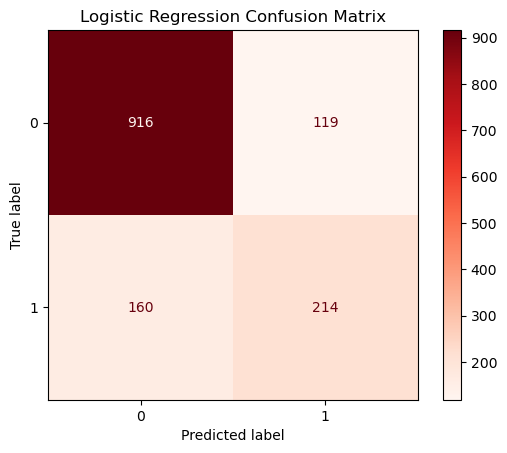

In [87]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    cmap="Reds"
)

plt.title("Logistic Regression Confusion Matrix")

plt.show()

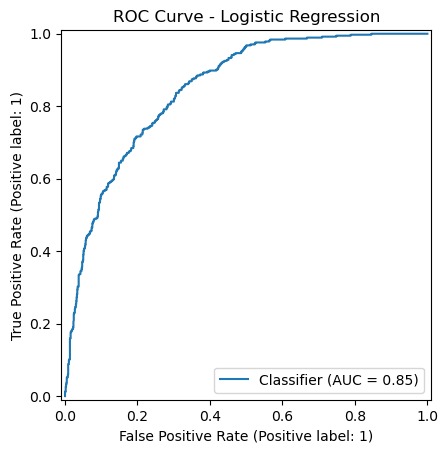

In [43]:
RocCurveDisplay.from_predictions(
    y_test,
    y_prob
)

plt.title("ROC Curve - Logistic Regression")

plt.show()

In [44]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    log_reg,
    X_train,
    y_train,
    cv=5,
    scoring="roc_auc"
)

print(scores)

print("Average ROC AUC:", scores.mean())

[0.87283295 0.86628132 0.86591779 0.85244293 0.83754191]
Average ROC AUC: 0.8590033808590872


In [45]:
results = X_test.copy()

results["Actual Churn"] = y_test.values
results["Predicted Churn"] = y_pred
results["Probability of Churn"] = y_prob.round(3)

results.head(15)

,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,...,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Actual Churn,Predicted Churn,Probability of Churn
2196,Male,No,Yes,No,72,Yes,Yes,Fiber optic,Yes,Yes,...,Yes,Yes,Two year,Yes,Credit card (automatic),114.05,8468.20,0,0,0.076
3549,Female,Yes,No,No,8,Yes,Yes,Fiber optic,No,No,...,Yes,Yes,Month-to-month,Yes,Credit card (automatic),100.15,908.55,0,1,0.672
3515,Female,No,Yes,No,41,Yes,Yes,DSL,Yes,Yes,...,Yes,No,One year,Yes,Credit card (automatic),78.35,3211.20,0,0,0.103
5162,Male,No,Yes,No,18,Yes,No,Fiber optic,No,No,...,No,No,Month-to-month,No,Electronic check,78.20,1468.75,0,0,0.472
4642,Female,No,Yes,No,72,Yes,Yes,DSL,Yes,Yes,...,Yes,Yes,Two year,Yes,Credit card (automatic),82.65,5919.35,0,0,0.031
6096,Female,No,No,No,21,Yes,Yes,Fiber optic,No,Yes,...,Yes,Yes,Month-to-month,Yes,Credit card (automatic),99.85,1992.55,0,1,0.620
4504,Female,No,No,No,21,Yes,No,Fiber optic,No,Yes,...,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),99.15,1956.40,0,0,0.466
4067,Male,No,No,Yes,19,Yes,Yes,No,No internet service,No internet service,...,No internet service,No internet service,Month-to-month,Yes,Credit card (automatic),24.10,439.20,0,0,0.042
6233,Female,No,Yes,Yes,61,Yes,No,No,No internet service,No internet service,...,No internet service,No internet service,Two year,No,Credit card (automatic),19.75,1311.60,0,0,0.001
430,Male,Yes,No,No,17,Yes,No,DSL,No,No,...,No,No,Month-to-month,Yes,Electronic check,45.05,770.60,1,0,0.388


In [46]:
results = X_test.copy()

results["CustomerID"] = df.loc[X_test.index, "CustomerID"]

results["Actual Churn"] = y_test.values
results["Predicted Churn"] = y_pred
results["Churn Probability"] = y_prob

results.head()

,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,...,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,CustomerID,Actual Churn,Predicted Churn,Churn Probability
2196,Male,No,Yes,No,72,Yes,Yes,Fiber optic,Yes,Yes,...,Yes,Two year,Yes,Credit card (automatic),114.05,8468.20,4376-KFVRS,0,0,0.075955
3549,Female,Yes,No,No,8,Yes,Yes,Fiber optic,No,No,...,Yes,Month-to-month,Yes,Credit card (automatic),100.15,908.55,2754-SDJRD,0,1,0.671970
3515,Female,No,Yes,No,41,Yes,Yes,DSL,Yes,Yes,...,No,One year,Yes,Credit card (automatic),78.35,3211.20,9917-KWRBE,0,0,0.102644
5162,Male,No,Yes,No,18,Yes,No,Fiber optic,No,No,...,No,Month-to-month,No,Electronic check,78.20,1468.75,0365-GXEZS,0,0,0.472039
4642,Female,No,Yes,No,72,Yes,Yes,DSL,Yes,Yes,...,Yes,Two year,Yes,Credit card (automatic),82.65,5919.35,9385-NXKDA,0,0,0.031073


In [47]:
results["Predicted Churn"].value_counts()

Predicted Churn
0    1076
1     333
Name: count, dtype: int64

In [48]:
results["Actual Churn"].value_counts()

Actual Churn
0    1035
1     374
Name: count, dtype: int64

In [49]:
true_positives = results[
    (results["Actual Churn"] == 1) &
    (results["Predicted Churn"] == 1)
]

true_positives.head(5)

,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,...,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,CustomerID,Actual Churn,Predicted Churn,Churn Probability
917,Female,Yes,No,No,11,Yes,Yes,Fiber optic,No,No,...,Yes,Month-to-month,Yes,Credit card (automatic),84.80,906.85,4706-AXVKM,1,1,0.670435
1727,Male,Yes,No,No,2,Yes,Yes,Fiber optic,No,No,...,No,Month-to-month,Yes,Mailed check,74.85,156.40,7235-NXZCP,1,1,0.715387
186,Female,No,No,No,22,Yes,No,Fiber optic,No,No,...,Yes,Month-to-month,No,Electronic check,89.25,1907.85,1894-IGFSG,1,1,0.584697
1615,Male,No,Yes,No,13,Yes,Yes,Fiber optic,No,No,...,Yes,Month-to-month,Yes,Credit card (automatic),102.25,1359.00,0871-URUWO,1,1,0.753160
1459,Female,No,No,No,3,Yes,No,Fiber optic,No,No,...,Yes,Month-to-month,Yes,Electronic check,89.45,240.45,9611-CTWIH,1,1,0.785825


In [50]:
len(true_positives)

214

In [51]:
false_positives = results[
    (results["Actual Churn"] == 0) &
    (results["Predicted Churn"] == 1)
]

false_positives.head(5)

,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,...,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,CustomerID,Actual Churn,Predicted Churn,Churn Probability
3549,Female,Yes,No,No,8,Yes,Yes,Fiber optic,No,No,...,Yes,Month-to-month,Yes,Credit card (automatic),100.15,908.55,2754-SDJRD,0,1,0.671970
6096,Female,No,No,No,21,Yes,Yes,Fiber optic,No,Yes,...,Yes,Month-to-month,Yes,Credit card (automatic),99.85,1992.55,4686-UXDML,0,1,0.620079
3732,Male,No,Yes,No,2,Yes,Yes,Fiber optic,No,No,...,No,Month-to-month,Yes,Electronic check,91.45,171.45,4927-WWOOZ,0,1,0.837339
4464,Female,No,No,No,8,Yes,Yes,Fiber optic,No,No,...,No,Month-to-month,Yes,Electronic check,75.25,576.70,3199-XGZCY,0,1,0.725598
6514,Female,No,No,No,6,Yes,Yes,Fiber optic,No,No,...,No,Month-to-month,Yes,Mailed check,73.85,401.30,8873-GLDMH,0,1,0.678615


In [52]:
false_negatives = results[
    (results["Actual Churn"] == 1) &
    (results["Predicted Churn"] == 0)
]

false_negatives.head(5)

,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,...,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,CustomerID,Actual Churn,Predicted Churn,Churn Probability
430,Male,Yes,No,No,17,Yes,No,DSL,No,No,...,No,Month-to-month,Yes,Electronic check,45.05,770.60,4690-LLKUA,1,0,0.388098
240,Male,Yes,No,No,2,Yes,No,DSL,No,No,...,No,Month-to-month,No,Mailed check,44.95,85.15,4208-UFFGW,1,0,0.377359
648,Male,No,No,No,31,Yes,No,DSL,No,No,...,No,Month-to-month,Yes,Electronic check,55.25,1715.65,4701-MLJPN,1,0,0.193348
134,Female,No,No,No,23,Yes,Yes,Fiber optic,No,No,...,No,Month-to-month,No,Bank transfer (automatic),75.60,1758.60,6825-UYPFK,1,0,0.432994
1334,Male,No,No,No,45,Yes,No,No,No internet service,No internet service,...,No internet service,One year,Yes,Electronic check,20.40,930.45,3705-PSNGL,1,0,0.033344


In [53]:
len(false_negatives)

160

In [54]:
summary = pd.DataFrame({
    "Count": [
        len(true_positives),
        len(false_positives),
        len(false_negatives),
        len(results[(results["Actual Churn"] == 0) &
                    (results["Predicted Churn"] == 0)])
    ]
},
index=[
    "True Positives",
    "False Positives",
    "False Negatives",
    "True Negatives"
])

summary

,Count
True Positives,214
False Positives,119
False Negatives,160
True Negatives,916


In [55]:
results.sort_values(
    "Churn Probability",
    ascending=False
).head(20)

,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,...,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,CustomerID,Actual Churn,Predicted Churn,Churn Probability
886,Male,Yes,Yes,No,1,Yes,Yes,Fiber optic,No,No,...,Yes,Month-to-month,Yes,Electronic check,95.10,95.10,5178-LMXOP,1,1,0.879275
684,Male,Yes,Yes,No,7,Yes,Yes,Fiber optic,No,No,...,Yes,Month-to-month,Yes,Electronic check,99.25,665.45,6861-XWTWQ,1,1,0.852358
1681,Male,Yes,Yes,No,7,Yes,Yes,Fiber optic,No,No,...,Yes,Month-to-month,Yes,Electronic check,101.95,700.85,8884-ADFVN,1,1,0.848737
1827,Male,Yes,Yes,No,3,Yes,Yes,Fiber optic,No,Yes,...,Yes,Month-to-month,Yes,Electronic check,105.90,334.65,1400-MMYXY,1,1,0.846573
2567,Female,Yes,Yes,No,4,Yes,Yes,Fiber optic,No,No,...,No,Month-to-month,Yes,Electronic check,83.25,308.05,6630-UJZMY,0,1,0.843760
1818,Male,No,No,No,1,Yes,Yes,Fiber optic,No,No,...,Yes,Month-to-month,Yes,Electronic check,95.45,95.45,0295-PPHDO,1,1,0.841524
3732,Male,No,Yes,No,2,Yes,Yes,Fiber optic,No,No,...,No,Month-to-month,Yes,Electronic check,91.45,171.45,4927-WWOOZ,0,1,0.837339
978,Female,No,No,No,3,Yes,Yes,Fiber optic,No,No,...,Yes,Month-to-month,Yes,Electronic check,96.60,291.90,9057-SIHCH,1,1,0.829719
1044,Female,No,Yes,No,6,Yes,Yes,Fiber optic,No,Yes,...,Yes,Month-to-month,Yes,Electronic check,105.30,545.20,4587-VVTOX,1,1,0.828080
731,Male,No,No,No,3,Yes,Yes,Fiber optic,No,No,...,Yes,Month-to-month,Yes,Electronic check,100.95,329.95,6023-YEBUP,1,1,0.824815


In [56]:
results.groupby("Predicted Churn")[[
    "Tenure Months",
    "Monthly Charges",
    "Total Charges"
]].mean().round(2)

,Tenure Months,Monthly Charges,Total Charges
Predicted Churn,,,
0,38.16,59.56,2564.22
1,11.75,78.73,1028.89


In [57]:
results.groupby("Actual Churn")[[
    "Tenure Months",
    "Monthly Charges",
    "Total Charges"
]].mean().round(2)

,Tenure Months,Monthly Charges,Total Charges
Actual Churn,,,
0,37.50,60.95,2490.68
1,16.46,72.77,1400.72


# Model Prediction Summary

The Logistic Regression model correctly identified 214 customers who ultimately churned (true positives) while correctly predicting 916 customers who remained (true negatives). The model incorrectly predicted churn for 119 customers who ultimately stayed (false positives) and failed to identify 160 customers who actually churned (false negatives).

Overall, the model demonstrates a good ability to distinguish between customers who are likely to churn and those who are likely to remain, although it still misses a meaningful number of churning customers. Depending on business priorities, the decision threshold could be adjusted to improve recall if identifying more at-risk customers is more valuable than minimizing unnecessary retention efforts.

Characteristics of Predicted Churn Customers

Customers predicted to churn exhibited noticeably different characteristics than those predicted to remain:

- Predicted churn customers had much shorter average tenure (11.75 months vs. 38.16 months), indicating that newer customers are at substantially higher risk of leaving.
- Predicted churn customers paid higher monthly charges on average (78.73 vs. 59.56), suggesting that higher recurring costs may contribute to customer attrition.
- Predicted churn customers had significantly lower total charges (1,028.89 vs. 2,564.22), reflecting their shorter customer lifespan and lower overall lifetime value.

These findings align closely with the patterns observed during exploratory data analysis, reinforcing that customer tenure and monthly charges are among the strongest indicators of churn risk. From a business perspective, these insights suggest that retention efforts should prioritize newer customers with relatively high monthly service costs before they reach long-term customer status.

## Decision Tree Classifier

Decision Trees are non-parametric machine learning models that classify observations by recursively splitting the dataset based on feature values. Unlike Logistic Regression, Decision Trees can capture nonlinear relationships and interactions between variables without requiring feature scaling or assumptions about linearity.

The model is evaluated using the same training and testing datasets to provide a direct comparison with the Logistic Regression baseline.

In [58]:
from sklearn.tree import DecisionTreeClassifier

In [59]:
decision_tree = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", DecisionTreeClassifier(random_state=42))
    ]
)

In [60]:
decision_tree.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numeric',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Tenure Months',
                                                   'Monthly Charges',
                                                   'Total Charges']),
                                                 ('categorical',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore'))]),
                                                  ['Gender', 'Senior Citizen',
                                                   'Partner', 'Dependents',
                                                   'Phone Service',
                                                   'Multiple Lines',
                                                   'Internet Service',
                                                   'Online Security',
                                                   'Online Backup',
                                                   'Device Protection',
                                                   'Tech Support',
                                                   'Streaming TV',
                                                   'Streaming Movies',
                                                   'Contract',
                                                   'Paperless Billing',
                                                   'Payment Method'])])),
                ('classifier', DecisionTreeClassifier(random_state=42))])

In [61]:
dt_pred = decision_tree.predict(X_test)

dt_prob = decision_tree.predict_proba(X_test)[:, 1]

In [62]:
print("Accuracy :", round(accuracy_score(y_test, dt_pred),3))
print("Precision:", round(precision_score(y_test, dt_pred),3))
print("Recall   :", round(recall_score(y_test, dt_pred),3))
print("F1 Score :", round(f1_score(y_test, dt_pred),3))
print("ROC AUC  :", round(roc_auc_score(y_test, dt_prob),3))

Accuracy : 0.727
Precision: 0.485
Recall   : 0.468
F1 Score : 0.476
ROC AUC  : 0.644


In [63]:
print(classification_report(y_test, dt_pred))

              precision    recall  f1-score   support

           0       0.81      0.82      0.82      1035
           1       0.48      0.47      0.48       374

    accuracy                           0.73      1409
   macro avg       0.65      0.64      0.65      1409
weighted avg       0.72      0.73      0.73      1409



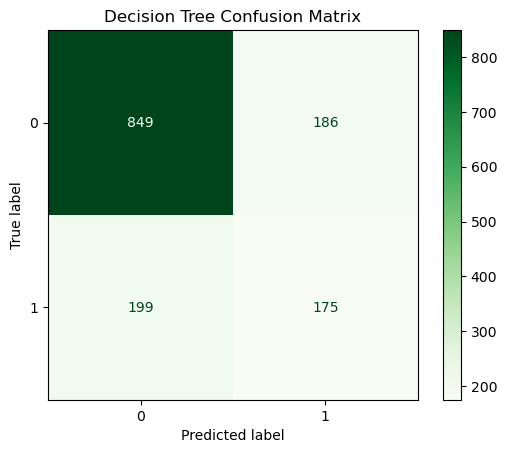

In [86]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    dt_pred,
    cmap="Greens"
)

plt.title("Decision Tree Confusion Matrix")

plt.show()

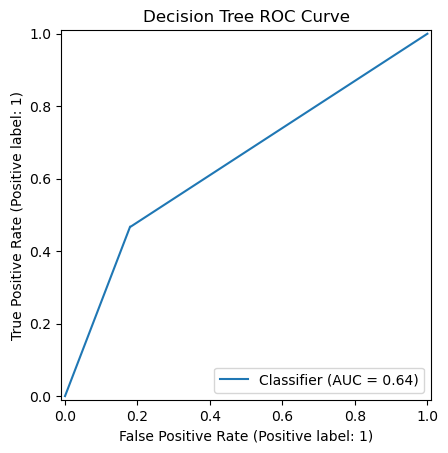

In [65]:
RocCurveDisplay.from_predictions(
    y_test,
    dt_prob
)

plt.title("Decision Tree ROC Curve")

plt.show()

In [66]:
dt_scores = cross_val_score(
    decision_tree,
    X_train,
    y_train,
    cv=5,
    scoring="roc_auc"
)

print(dt_scores)

print("Average ROC AUC:", round(dt_scores.mean(),3))

[0.64319471 0.66556598 0.64980491 0.66267187 0.67706947]
Average ROC AUC: 0.66


In [67]:
dt_results = X_test.copy()

dt_results["Actual Churn"] = y_test.values
dt_results["Predicted Churn"] = dt_pred
dt_results["Churn Probability"] = dt_prob

dt_results.head()

,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,...,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Actual Churn,Predicted Churn,Churn Probability
2196,Male,No,Yes,No,72,Yes,Yes,Fiber optic,Yes,Yes,...,Yes,Yes,Two year,Yes,Credit card (automatic),114.05,8468.20,0,0,0.0
3549,Female,Yes,No,No,8,Yes,Yes,Fiber optic,No,No,...,Yes,Yes,Month-to-month,Yes,Credit card (automatic),100.15,908.55,0,1,1.0
3515,Female,No,Yes,No,41,Yes,Yes,DSL,Yes,Yes,...,Yes,No,One year,Yes,Credit card (automatic),78.35,3211.20,0,0,0.0
5162,Male,No,Yes,No,18,Yes,No,Fiber optic,No,No,...,No,No,Month-to-month,No,Electronic check,78.20,1468.75,0,0,0.0
4642,Female,No,Yes,No,72,Yes,Yes,DSL,Yes,Yes,...,Yes,Yes,Two year,Yes,Credit card (automatic),82.65,5919.35,0,0,0.0


In [68]:
dt_results.groupby("Predicted Churn")[[
    "Tenure Months",
    "Monthly Charges",
    "Total Charges"
]].mean().round(2)

,Tenure Months,Monthly Charges,Total Charges
Predicted Churn,,,
0,36.44,60.37,2421.33
1,18.78,74.89,1562.79


In [69]:
comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred),
        accuracy_score(y_test, dt_pred)
    ],
    "Precision": [
        precision_score(y_test, y_pred),
        precision_score(y_test, dt_pred)
    ],
    "Recall": [
        recall_score(y_test, y_pred),
        recall_score(y_test, dt_pred)
    ],
    "F1 Score": [
        f1_score(y_test, y_pred),
        f1_score(y_test, dt_pred)
    ],
    "ROC AUC": [
        roc_auc_score(y_test, y_prob),
        roc_auc_score(y_test, dt_prob)
    ]
})

comparison = comparison.round(3)

comparison

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Logistic Regression,0.802,0.643,0.572,0.605,0.849
1,Decision Tree,0.727,0.485,0.468,0.476,0.644


## Random Forest Classifier

Random Forest is an ensemble learning algorithm that combines the predictions of many decision trees to improve generalization and reduce overfitting. Each tree is trained on a random sample of the data while considering a random subset of features at each split.

Compared to a single Decision Tree, Random Forests typically produce more accurate and stable predictions while also providing feature importance scores that help identify the variables most strongly associated with customer churn.

In [70]:
from sklearn.ensemble import RandomForestClassifier

In [71]:
random_forest = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier",
         RandomForestClassifier(
             n_estimators=200,
             random_state=42,
             n_jobs=-1
         ))
    ]
)

In [72]:
random_forest.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numeric',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Tenure Months',
                                                   'Monthly Charges',
                                                   'Total Charges']),
                                                 ('categorical',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore'))]),
                                                  ['Gender', 'Senior Citizen',
                                                   'Partner', 'Dependents',
                                                   'Phone Service',
                                                   'Multiple Lines',
                                                   'Internet Service',
                                                   'Online Security',
                                                   'Online Backup',
                                                   'Device Protection',
                                                   'Tech Support',
                                                   'Streaming TV',
                                                   'Streaming Movies',
                                                   'Contract',
                                                   'Paperless Billing',
                                                   'Payment Method'])])),
                ('classifier',
                 RandomForestClassifier(n_estimators=200, n_jobs=-1,
                                        random_state=42))])

In [73]:
rf_pred = random_forest.predict(X_test)

rf_prob = random_forest.predict_proba(X_test)[:,1]

In [74]:
print("Accuracy :", round(accuracy_score(y_test, rf_pred),3))
print("Precision:", round(precision_score(y_test, rf_pred),3))
print("Recall   :", round(recall_score(y_test, rf_pred),3))
print("F1 Score :", round(f1_score(y_test, rf_pred),3))
print("ROC AUC  :", round(roc_auc_score(y_test, rf_prob),3))

Accuracy : 0.793
Precision: 0.634
Recall   : 0.524
F1 Score : 0.574
ROC AUC  : 0.835


In [75]:
print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       0.84      0.89      0.86      1035
           1       0.63      0.52      0.57       374

    accuracy                           0.79      1409
   macro avg       0.74      0.71      0.72      1409
weighted avg       0.78      0.79      0.79      1409



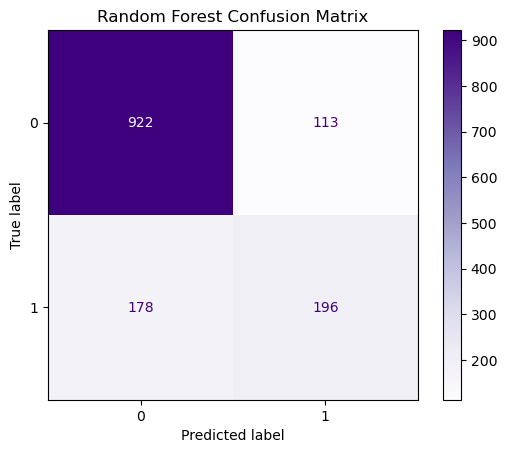

In [76]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    rf_pred,
    cmap="Purples"
)

plt.title("Random Forest Confusion Matrix")

plt.show()

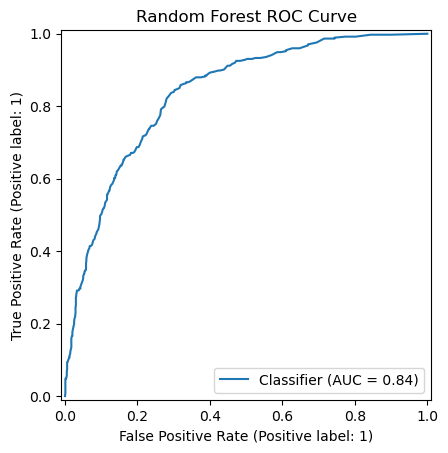

In [77]:
RocCurveDisplay.from_predictions(
    y_test,
    rf_prob
)

plt.title("Random Forest ROC Curve")

plt.show()

In [78]:
rf_scores = cross_val_score(
    random_forest,
    X_train,
    y_train,
    cv=5,
    scoring="roc_auc"
)

print(rf_scores)

print("Average ROC AUC:", round(rf_scores.mean(),3))

[0.85579952 0.84667693 0.84508749 0.8305604  0.82530038]
Average ROC AUC: 0.841


In [79]:
comparison = pd.DataFrame({
    "Model":[
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy":[
        accuracy_score(y_test, y_pred),
        accuracy_score(y_test, dt_pred),
        accuracy_score(y_test, rf_pred)
    ],
    "Precision":[
        precision_score(y_test, y_pred),
        precision_score(y_test, dt_pred),
        precision_score(y_test, rf_pred)
    ],
    "Recall":[
        recall_score(y_test, y_pred),
        recall_score(y_test, dt_pred),
        recall_score(y_test, rf_pred)
    ],
    "F1 Score":[
        f1_score(y_test, y_pred),
        f1_score(y_test, dt_pred),
        f1_score(y_test, rf_pred)
    ],
    "ROC AUC":[
        roc_auc_score(y_test, y_prob),
        roc_auc_score(y_test, dt_prob),
        roc_auc_score(y_test, rf_prob)
    ]
})

comparison.round(3)

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Logistic Regression,0.802,0.643,0.572,0.605,0.849
1,Decision Tree,0.727,0.485,0.468,0.476,0.644
2,Random Forest,0.793,0.634,0.524,0.574,0.835


In [80]:
rf_results = X_test.copy()

rf_results["Actual Churn"] = y_test.values
rf_results["Predicted Churn"] = rf_pred
rf_results["Churn Probability"] = rf_prob

rf_results.head()

,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,...,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Actual Churn,Predicted Churn,Churn Probability
2196,Male,No,Yes,No,72,Yes,Yes,Fiber optic,Yes,Yes,...,Yes,Yes,Two year,Yes,Credit card (automatic),114.05,8468.20,0,0,0.000
3549,Female,Yes,No,No,8,Yes,Yes,Fiber optic,No,No,...,Yes,Yes,Month-to-month,Yes,Credit card (automatic),100.15,908.55,0,1,0.740
3515,Female,No,Yes,No,41,Yes,Yes,DSL,Yes,Yes,...,Yes,No,One year,Yes,Credit card (automatic),78.35,3211.20,0,0,0.070
5162,Male,No,Yes,No,18,Yes,No,Fiber optic,No,No,...,No,No,Month-to-month,No,Electronic check,78.20,1468.75,0,0,0.415
4642,Female,No,Yes,No,72,Yes,Yes,DSL,Yes,Yes,...,Yes,Yes,Two year,Yes,Credit card (automatic),82.65,5919.35,0,0,0.005


In [81]:
rf_results.groupby("Predicted Churn")[[
    "Tenure Months",
    "Monthly Charges",
    "Total Charges"
]].mean().round(2)

,Tenure Months,Monthly Charges,Total Charges
Predicted Churn,,,
0,37.79,60.75,2552.63
1,11.01,75.96,950.90


In [82]:
rf_results.groupby("Actual Churn")[[
    "Tenure Months",
    "Monthly Charges",
    "Total Charges"
]].mean().round(2)

,Tenure Months,Monthly Charges,Total Charges
Actual Churn,,,
0,37.50,60.95,2490.68
1,16.46,72.77,1400.72


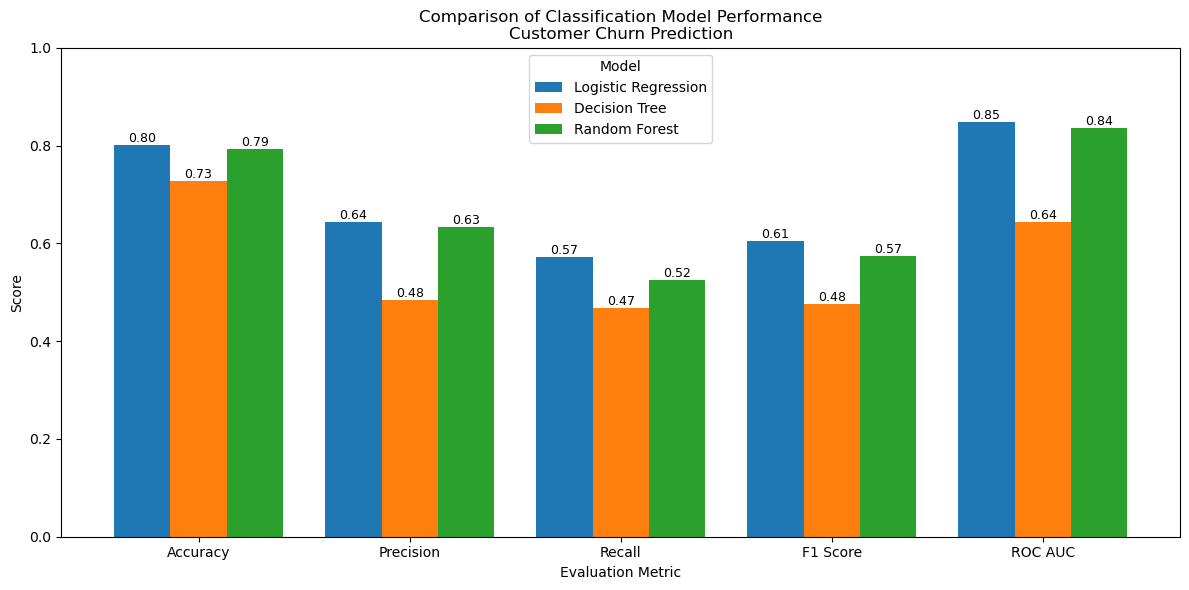

In [88]:
# Reshape data for plotting
comparison_plot = comparison.set_index("Model").T

ax = comparison_plot.plot(
    kind="bar",
    figsize=(12,6),
    width=0.8
)

plt.title(
    "Comparison of Classification Model Performance\n"
    "Customer Churn Prediction"
)
plt.xlabel("Evaluation Metric")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.ylim(0, 1)

plt.legend(title="Model")

# Add value labels
for container in ax.containers:
    ax.bar_label(container, fmt="%.2f", fontsize=9)

plt.tight_layout()

## Model Comparison

Three classification algorithms were evaluated to predict customer churn. Logistic Regression achieved the strongest overall performance, with the highest accuracy (80.2%), precision (64.3%), recall (57.2%), F1-score (60.5%), and ROC-AUC (0.849). Although the Random Forest model substantially improved upon the single Decision Tree by reducing overfitting and increasing predictive performance across all metrics, it did not surpass the Logistic Regression baseline. These results suggest that the relationships between customer characteristics and churn are effectively captured by a linear decision boundary, making Logistic Regression the preferred model for this dataset due to its strong performance, interpretability, and computational efficiency.

## Random Forest Hyperparameter Tuning

The initial Random Forest model substantially outperformed the single Decision Tree but did not exceed the Logistic Regression baseline. To determine whether its performance could be improved, hyperparameter tuning was conducted using randomized cross-validation.

The search evaluates multiple combinations of tree depth, split requirements, feature sampling, and class weighting. ROC-AUC is used as the optimization metric because it measures the model's ability to distinguish between customers who churn and those who remain across classification thresholds.

In [89]:
from sklearn.model_selection import RandomizedSearchCV

In [90]:
param_distributions = {
    "classifier__n_estimators": [200, 300, 500, 700],
    "classifier__max_depth": [None, 5, 10, 15, 20, 30],
    "classifier__min_samples_split": [2, 5, 10, 15],
    "classifier__min_samples_leaf": [1, 2, 4, 8],
    "classifier__max_features": ["sqrt", "log2", 0.5],
    "classifier__class_weight": [None, "balanced", "balanced_subsample"]
}

In [91]:
rf_random_search = RandomizedSearchCV(
    estimator=random_forest,
    param_distributions=param_distributions,
    n_iter=40,
    scoring="roc_auc",
    cv=5,
    random_state=42,
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)

In [92]:
rf_random_search.fit(X_train, y_train)

Fitting 5 folds for each of 40 candidates, totalling 200 fits


RandomizedSearchCV(cv=5,
                   estimator=Pipeline(steps=[('preprocessor',
                                              ColumnTransformer(transformers=[('numeric',
                                                                               Pipeline(steps=[('imputer',
                                                                                                SimpleImputer(strategy='median')),
                                                                                               ('scaler',
                                                                                                StandardScaler())]),
                                                                               ['Tenure '
                                                                                'Months',
                                                                                'Monthly '
                                                                                'Charges',
                                                                                'Total '
                                                                                'Charges']),
                                                                              ('categorical',
                                                                               Pipeline(steps=[('imputer',
                                                                                                SimpleImputer(strategy='most_frequent')),
                                                                                               ('onehot',
                                                                                                O...
                   param_distributions={'classifier__class_weight': [None,
                                                                     'balanced',
                                                                     'balanced_subsample'],
                                        'classifier__max_depth': [None, 5, 10,
                                                                  15, 20, 30],
                                        'classifier__max_features': ['sqrt',
                                                                     'log2',
                                                                     0.5],
                                        'classifier__min_samples_leaf': [1, 2,
                                                                         4, 8],
                                        'classifier__min_samples_split': [2, 5,
                                                                          10,
                                                                          15],
                                        'classifier__n_estimators': [200, 300,
                                                                     500,
                                                                     700]},
                   random_state=42, return_train_score=True, scoring='roc_auc',
                   verbose=1)

In [93]:
print("Best Parameters:")
print(rf_random_search.best_params_)

print("\nBest Cross-Validated ROC-AUC:")
print(round(rf_random_search.best_score_, 3))

Best Parameters:
{'classifier__n_estimators': 300, 'classifier__min_samples_split': 5, 'classifier__min_samples_leaf': 4, 'classifier__max_features': 'sqrt', 'classifier__max_depth': 10, 'classifier__class_weight': 'balanced_subsample'}

Best Cross-Validated ROC-AUC:
0.861


In [94]:
print("Best Parameters:")
print(rf_random_search.best_params_)

print("\nBest Cross-Validated ROC-AUC:")
print(round(rf_random_search.best_score_, 3))

Best Parameters:
{'classifier__n_estimators': 300, 'classifier__min_samples_split': 5, 'classifier__min_samples_leaf': 4, 'classifier__max_features': 'sqrt', 'classifier__max_depth': 10, 'classifier__class_weight': 'balanced_subsample'}

Best Cross-Validated ROC-AUC:
0.861


In [95]:
tuned_random_forest = rf_random_search.best_estimator_

In [96]:
tuned_rf_pred = tuned_random_forest.predict(X_test)
tuned_rf_prob = tuned_random_forest.predict_proba(X_test)[:, 1]

In [97]:
print("Accuracy :", round(accuracy_score(y_test, tuned_rf_pred), 3))
print("Precision:", round(precision_score(y_test, tuned_rf_pred), 3))
print("Recall   :", round(recall_score(y_test, tuned_rf_pred), 3))
print("F1 Score :", round(f1_score(y_test, tuned_rf_pred), 3))
print("ROC AUC  :", round(roc_auc_score(y_test, tuned_rf_prob), 3))

Accuracy : 0.769
Precision: 0.547
Recall   : 0.767
F1 Score : 0.638
ROC AUC  : 0.854


In [98]:
print(classification_report(y_test, tuned_rf_pred))

              precision    recall  f1-score   support

           0       0.90      0.77      0.83      1035
           1       0.55      0.77      0.64       374

    accuracy                           0.77      1409
   macro avg       0.72      0.77      0.73      1409
weighted avg       0.81      0.77      0.78      1409



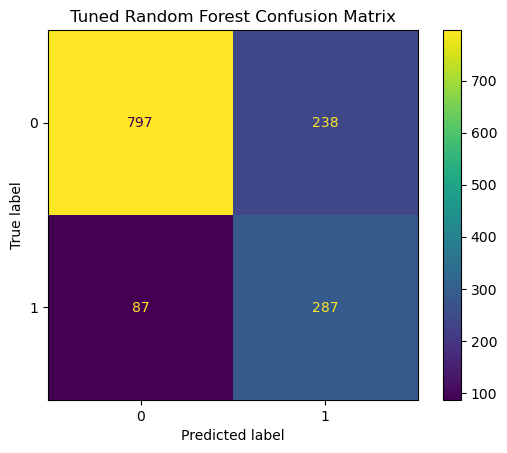

In [99]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    tuned_rf_pred
)

plt.title("Tuned Random Forest Confusion Matrix")
plt.show()

In [100]:
tuning_comparison = pd.DataFrame({
    "Model": [
        "Original Random Forest",
        "Tuned Random Forest"
    ],
    "Accuracy": [
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, tuned_rf_pred)
    ],
    "Precision": [
        precision_score(y_test, rf_pred),
        precision_score(y_test, tuned_rf_pred)
    ],
    "Recall": [
        recall_score(y_test, rf_pred),
        recall_score(y_test, tuned_rf_pred)
    ],
    "F1 Score": [
        f1_score(y_test, rf_pred),
        f1_score(y_test, tuned_rf_pred)
    ],
    "ROC AUC": [
        roc_auc_score(y_test, rf_prob),
        roc_auc_score(y_test, tuned_rf_prob)
    ]
}).round(3)

tuning_comparison

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Original Random Forest,0.793,0.634,0.524,0.574,0.835
1,Tuned Random Forest,0.769,0.547,0.767,0.638,0.854


In [101]:
comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "Tuned Random Forest"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred),
        accuracy_score(y_test, dt_pred),
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, tuned_rf_pred)
    ],
    "Precision": [
        precision_score(y_test, y_pred),
        precision_score(y_test, dt_pred),
        precision_score(y_test, rf_pred),
        precision_score(y_test, tuned_rf_pred)
    ],
    "Recall": [
        recall_score(y_test, y_pred),
        recall_score(y_test, dt_pred),
        recall_score(y_test, rf_pred),
        recall_score(y_test, tuned_rf_pred)
    ],
    "F1 Score": [
        f1_score(y_test, y_pred),
        f1_score(y_test, dt_pred),
        f1_score(y_test, rf_pred),
        f1_score(y_test, tuned_rf_pred)
    ],
    "ROC AUC": [
        roc_auc_score(y_test, y_prob),
        roc_auc_score(y_test, dt_prob),
        roc_auc_score(y_test, rf_prob),
        roc_auc_score(y_test, tuned_rf_prob)
    ]
}).round(3)

comparison

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Logistic Regression,0.802,0.643,0.572,0.605,0.849
1,Decision Tree,0.727,0.485,0.468,0.476,0.644
2,Random Forest,0.793,0.634,0.524,0.574,0.835
3,Tuned Random Forest,0.769,0.547,0.767,0.638,0.854


In [102]:
search_results = pd.DataFrame(rf_random_search.cv_results_)

best_result = search_results.loc[
    rf_random_search.best_index_,
    [
        "mean_train_score",
        "mean_test_score",
        "std_test_score"
    ]
]

best_result

mean_train_score    0.926525
mean_test_score     0.860753
std_test_score      0.011924
Name: 38, dtype: object

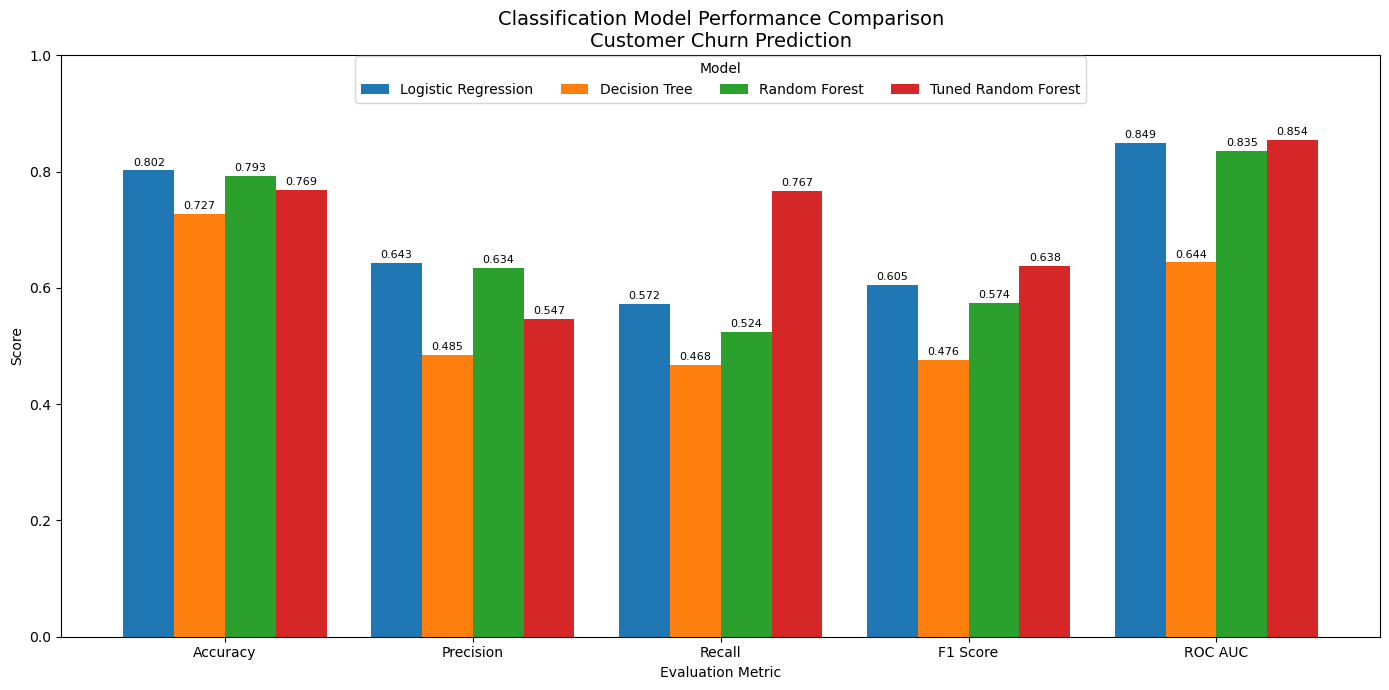

In [103]:
import matplotlib.pyplot as plt

# Put model names on the columns and evaluation metrics on the x-axis
comparison_plot = comparison.set_index("Model").T

ax = comparison_plot.plot(
    kind="bar",
    figsize=(14, 7),
    width=0.82
)

plt.title(
    "Classification Model Performance Comparison\n"
    "Customer Churn Prediction",
    fontsize=14
)
plt.xlabel("Evaluation Metric")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.ylim(0, 1)

plt.legend(
    title="Model",
    loc="upper center",
    bbox_to_anchor=(0.5, 1.01),
    ncol=4
)

# Display each metric value above its bar
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.3f",
        fontsize=8,
        padding=2
    )

plt.tight_layout()
plt.show()

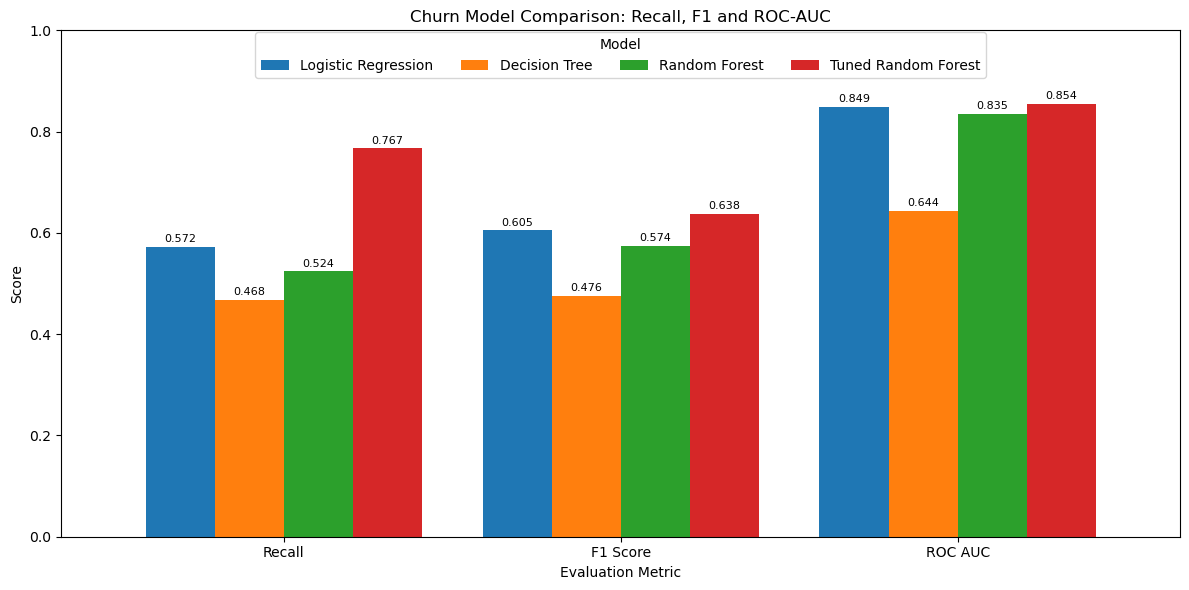

In [104]:
focused_comparison = comparison[
    ["Model", "Recall", "F1 Score", "ROC AUC"]
]

focused_plot = focused_comparison.set_index("Model").T

ax = focused_plot.plot(
    kind="bar",
    figsize=(12, 6),
    width=0.82
)

plt.title("Churn Model Comparison: Recall, F1 and ROC-AUC")
plt.xlabel("Evaluation Metric")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.ylim(0, 1)

plt.legend(
    title="Model",
    loc="upper center",
    bbox_to_anchor=(0.5, 1.01),
    ncol=4
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", fontsize=8, padding=2)

plt.tight_layout()
plt.show()

## Feature Importance

Feature importance was extracted from the tuned Random Forest to identify the customer characteristics that contributed most strongly to its churn predictions.

Because categorical variables were one-hot encoded during preprocessing, each encoded category is treated as an individual model feature. Higher importance values indicate that a feature contributed more frequently or more substantially to the Random Forest's decision-making process.

In [108]:
fitted_preprocessor = tuned_random_forest.named_steps["preprocessor"]
fitted_rf_classifier = tuned_random_forest.named_steps["classifier"]

In [109]:
feature_names = fitted_preprocessor.get_feature_names_out()

print("Number of transformed features:", len(feature_names))
print("Number of importance values:", len(fitted_rf_classifier.feature_importances_))

Number of transformed features: 30
Number of importance values: 30


In [115]:
feature_importance["Feature"] = (
    feature_importance["Feature"]
    .str.replace("numeric__", "", regex=False)
    .str.replace("categorical__", "", regex=False)
)

feature_importance.head(20)

,Feature,Importance
0,Tenure Months,0.169727
1,Total Charges,0.117659
2,Contract_Two year,0.112866
3,Dependents_Yes,0.084871
4,Monthly Charges,0.082891
5,Internet Service_Fiber optic,0.072755
6,Payment Method_Electronic check,0.051393
7,Contract_One year,0.041655
8,Online Security_Yes,0.031890
9,Tech Support_Yes,0.021516


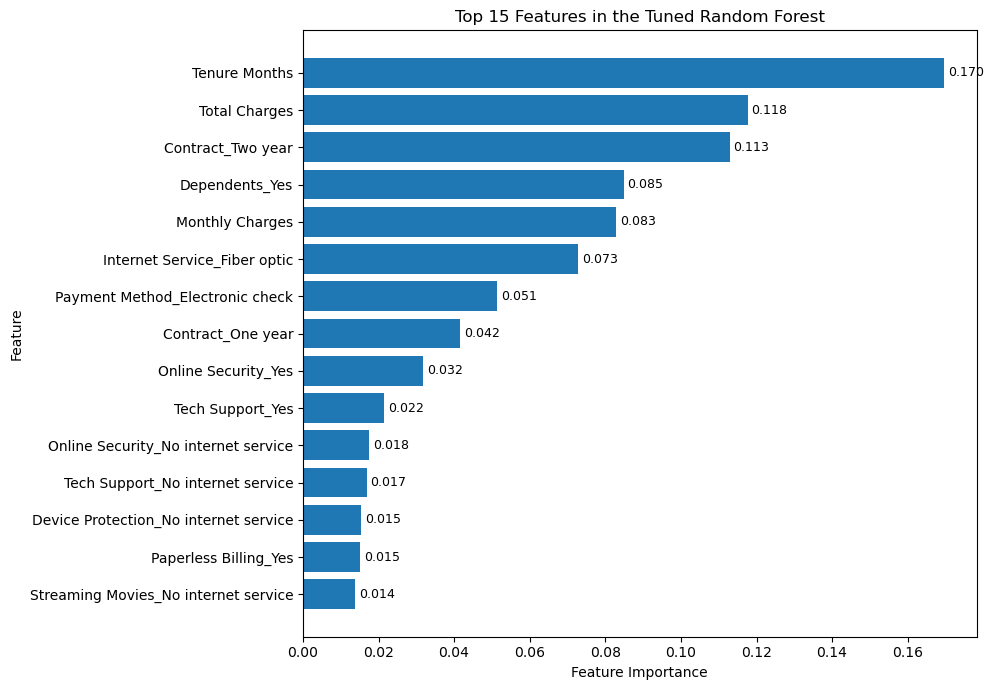

In [116]:
top_features = feature_importance.head(15).sort_values(
    by="Importance",
    ascending=True
)

plt.figure(figsize=(10, 7))

bars = plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.title("Top 15 Features in the Tuned Random Forest")
plt.xlabel("Feature Importance")
plt.ylabel("Feature")

for bar in bars:
    width = bar.get_width()

    plt.text(
        width + 0.001,
        bar.get_y() + bar.get_height() / 2,
        f"{width:.3f}",
        va="center",
        fontsize=9
    )

plt.tight_layout()
plt.show()

### Interpreting Feature Importance

The Random Forest importance values indicate how strongly each variable contributed to the model's predictions, but they do not identify the direction of the relationship. Therefore, the importance results should be interpreted alongside the exploratory analysis.

For example, if tenure appears as an important feature, the feature-importance analysis indicates that tenure strongly influences model predictions, while the exploratory analysis demonstrates that customers with shorter tenure are more likely to churn.

In [117]:
grouped_importance = feature_importance.copy()

categorical_feature_names = [
    "Gender",
    "Senior Citizen",
    "Partner",
    "Dependents",
    "Phone Service",
    "Multiple Lines",
    "Internet Service",
    "Online Security",
    "Online Backup",
    "Device Protection",
    "Tech Support",
    "Streaming TV",
    "Streaming Movies",
    "Contract",
    "Paperless Billing",
    "Payment Method"
]

def identify_original_feature(encoded_feature):
    for original_feature in categorical_feature_names:
        if encoded_feature.startswith(original_feature + "_"):
            return original_feature

    return encoded_feature

grouped_importance["Original Feature"] = grouped_importance["Feature"].apply(
    identify_original_feature
)

grouped_importance = (
    grouped_importance
    .groupby("Original Feature", as_index=False)["Importance"]
    .sum()
    .sort_values("Importance", ascending=False)
    .reset_index(drop=True)
)

grouped_importance.head(15)

,Original Feature,Importance
0,Tenure Months,0.169727
1,Contract,0.154521
2,Total Charges,0.117659
3,Internet Service,0.085477
4,Dependents,0.084871
5,Monthly Charges,0.082891
6,Payment Method,0.066425
7,Online Security,0.049424
8,Tech Support,0.038398
9,Device Protection,0.023128


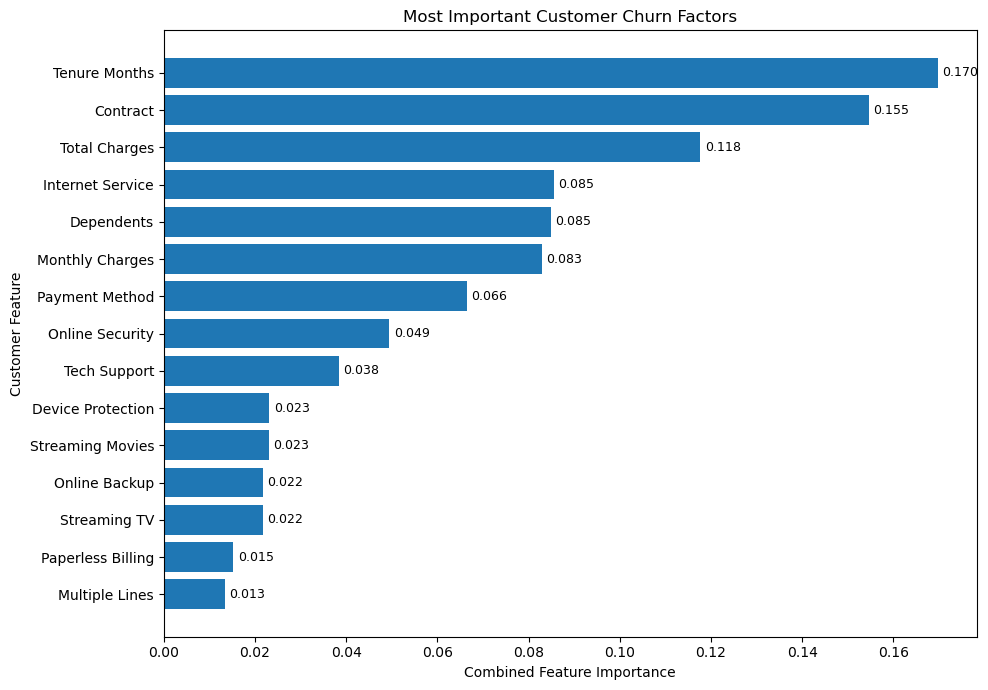

In [118]:
top_grouped_features = grouped_importance.head(15).sort_values(
    "Importance",
    ascending=True
)

plt.figure(figsize=(10, 7))

bars = plt.barh(
    top_grouped_features["Original Feature"],
    top_grouped_features["Importance"]
)

plt.title("Most Important Customer Churn Factors")
plt.xlabel("Combined Feature Importance")
plt.ylabel("Customer Feature")

for bar in bars:
    width = bar.get_width()

    plt.text(
        width + 0.001,
        bar.get_y() + bar.get_height() / 2,
        f"{width:.3f}",
        va="center",
        fontsize=9
    )

plt.tight_layout()
plt.show()

#### Interpreting Feature Importance

The Random Forest importance values indicate how strongly each variable contributed to the model's predictions, but they do not identify the direction of the relationship. Therefore, the importance results should be interpreted alongside the exploratory analysis.

#### Business Recommendations

Based on the feature importance analysis, several strategies could help reduce customer churn:

- Encourage customers to transition from month-to-month plans to longer-term contracts through promotional pricing or loyalty incentives.
- Focus retention efforts on new customers during their first year of service, when churn risk is highest.
- Evaluate pricing and customer satisfaction among fiber optic internet customers, who exhibited higher churn rates.
- Promote value-added services such as Online Security and Tech Support, which were associated with improved customer retention.
- Identify customers with high monthly charges and proactively offer plan reviews or targeted retention incentives before they consider leaving.

## Classification Threshold Tuning

Classification models output probabilities rather than fixed predictions. By default, customers with a predicted probability of 0.50 or greater are classified as likely to churn.

However, the default threshold may not align with business objectives. Lowering the threshold identifies more potential churners (increasing recall), while raising the threshold reduces false positives (increasing precision).

This analysis evaluates several classification thresholds to determine the most appropriate balance between precision and recall for customer retention.

In [119]:
thresholds = np.arange(0.30, 0.80, 0.05)

results = []

for threshold in thresholds:

    predictions = (tuned_rf_prob >= threshold).astype(int)

    results.append({
        "Threshold": threshold,
        "Accuracy": accuracy_score(y_test, predictions),
        "Precision": precision_score(y_test, predictions),
        "Recall": recall_score(y_test, predictions),
        "F1 Score": f1_score(y_test, predictions)
    })

threshold_results = pd.DataFrame(results)

threshold_results.round(3)

,Threshold,Accuracy,Precision,Recall,F1 Score
0,0.30,0.696,0.463,0.901,0.612
1,0.35,0.720,0.484,0.874,0.623
2,0.40,0.743,0.510,0.845,0.636
3,0.45,0.756,0.526,0.810,0.638
4,0.50,0.769,0.547,0.767,0.638
5,0.55,0.783,0.572,0.719,0.637
6,0.60,0.786,0.588,0.652,0.619
7,0.65,0.805,0.638,0.612,0.625
8,0.70,0.806,0.671,0.529,0.592
9,0.75,0.806,0.723,0.433,0.542


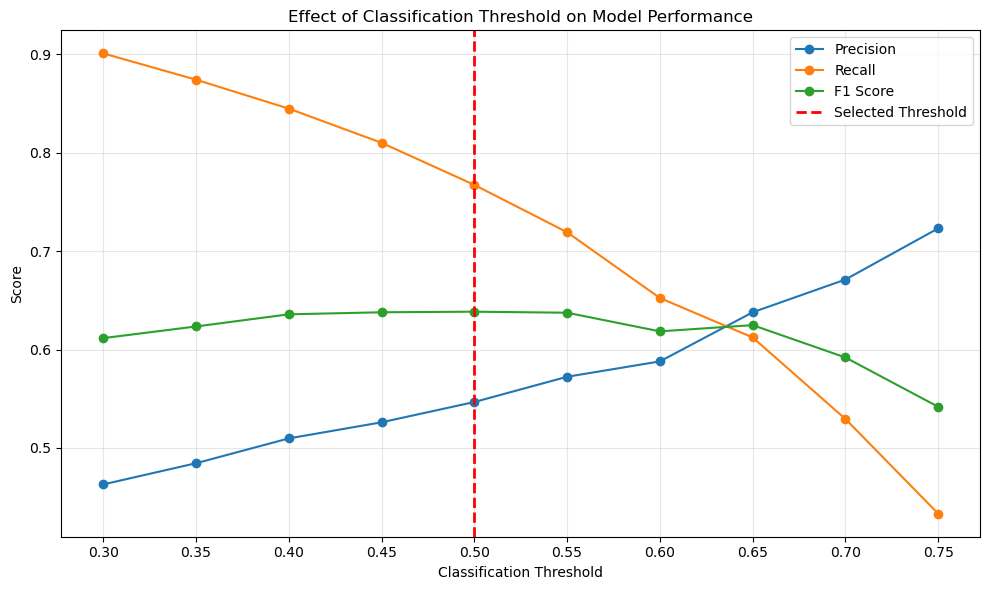

In [122]:
plt.figure(figsize=(10,6))

plt.plot(
    threshold_results["Threshold"],
    threshold_results["Precision"],
    marker="o",
    label="Precision"
)

plt.plot(
    threshold_results["Threshold"],
    threshold_results["Recall"],
    marker="o",
    label="Recall"
)

plt.plot(
    threshold_results["Threshold"],
    threshold_results["F1 Score"],
    marker="o",
    label="F1 Score"
)

plt.axvline(
    x=0.50,
    color="red",
    linestyle="--",
    linewidth=2,
    label="Selected Threshold"
)

plt.legend()
plt.xlabel("Classification Threshold")
plt.ylabel("Score")

plt.title("Effect of Classification Threshold on Model Performance")

plt.xticks(threshold_results["Threshold"])

plt.grid(alpha=0.3)

plt.legend()

plt.tight_layout()

plt.show()

In [121]:
threshold_results.sort_values(
    "F1 Score",
    ascending=False
).head()

,Threshold,Accuracy,Precision,Recall,F1 Score
4,0.50,0.769340,0.546667,0.767380,0.638487
3,0.45,0.755855,0.526042,0.810160,0.637895
5,0.55,0.782825,0.572340,0.719251,0.637441
2,0.40,0.743080,0.509677,0.844920,0.635815
7,0.65,0.804826,0.637883,0.612299,0.624829


### Threshold Tuning Results

Adjusting the classification threshold demonstrated the tradeoff between precision and recall. Lower thresholds classified more customers as likely to churn, substantially increasing recall while reducing precision. Higher thresholds produced the opposite effect, increasing precision at the expense of identifying fewer churning customers.

The highest F1-score (0.638) was achieved at thresholds of 0.45 and 0.50, indicating that the default threshold already provided an effective balance between precision and recall.

Although the default threshold remained the preferred operating point for balanced performance, organizations with different business objectives could select alternative thresholds. For example, a lower threshold would prioritize identifying nearly all at-risk customers, while a higher threshold would reduce unnecessary retention efforts by focusing only on customers with the highest predicted probability of churn.

If changing the threshold is determined to be a better business decision, changing to .55 would be the best decision because of the slightly higher precision and slightly lower recall. However, staying at .50 is best because of how close it is to the peak of the F-1 score.

## Precision-Recall Curve

While the ROC curve evaluates a model's ability to distinguish between classes across all classification thresholds, the Precision-Recall Curve focuses specifically on the tradeoff between precision and recall.

For customer churn prediction, the Precision-Recall Curve is particularly useful because the dataset is moderately imbalanced, with substantially fewer customers churning than remaining. This visualization helps evaluate how effectively the model identifies customers at risk of churn while minimizing false positive predictions.

In [123]:
from sklearn.metrics import PrecisionRecallDisplay
from sklearn.metrics import average_precision_score

<Figure size 800x600 with 0 Axes>

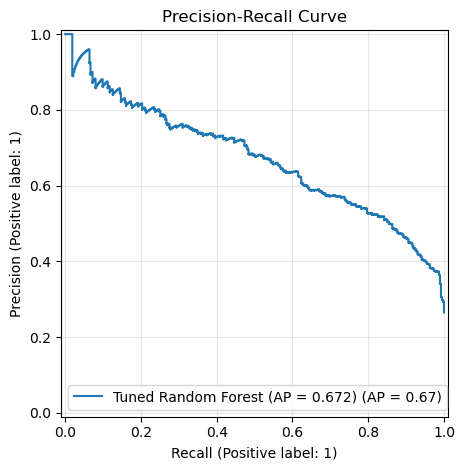

In [124]:
average_precision = average_precision_score(
    y_test,
    tuned_rf_prob
)

plt.figure(figsize=(8,6))

PrecisionRecallDisplay.from_predictions(
    y_test,
    tuned_rf_prob,
    name=f"Tuned Random Forest (AP = {average_precision:.3f})"
)

plt.title("Precision-Recall Curve")

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

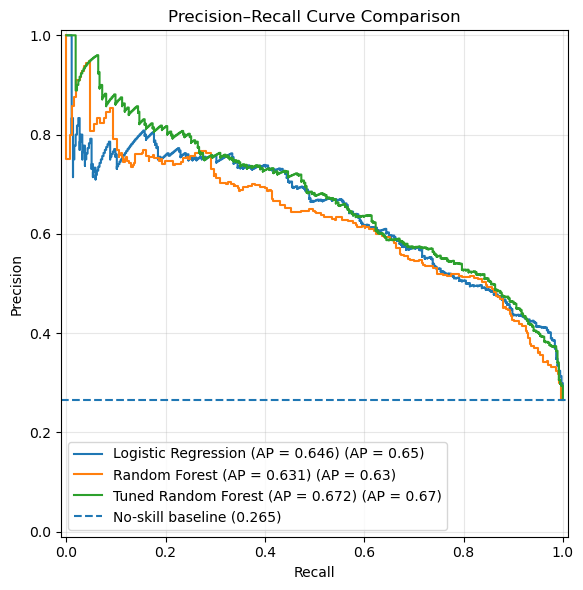

In [127]:
from sklearn.metrics import (
    PrecisionRecallDisplay,
    average_precision_score
)

fig, ax = plt.subplots(figsize=(9, 6))

PrecisionRecallDisplay.from_predictions(
    y_test,
    y_prob,
    name=(
        "Logistic Regression "
        f"(AP = {average_precision_score(y_test, y_prob):.3f})"
    ),
    ax=ax
)

PrecisionRecallDisplay.from_predictions(
    y_test,
    rf_prob,
    name=(
        "Random Forest "
        f"(AP = {average_precision_score(y_test, rf_prob):.3f})"
    ),
    ax=ax
)

PrecisionRecallDisplay.from_predictions(
    y_test,
    tuned_rf_prob,
    name=(
        "Tuned Random Forest "
        f"(AP = {average_precision_score(y_test, tuned_rf_prob):.3f})"
    ),
    ax=ax
)

# Baseline precision equals the test-set churn rate
baseline = y_test.mean()

ax.axhline(
    baseline,
    linestyle="--",
    label=f"No-skill baseline ({baseline:.3f})"
)

ax.set_title("Precision–Recall Curve Comparison")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.grid(alpha=0.3)
ax.legend(loc="lower left")

plt.tight_layout()
plt.show()

In [126]:
print("Average Precision Scores")

print("------------------------")

print(
    "Logistic Regression:",
    round(average_precision_score(y_test, y_prob),3)
)

print(
    "Random Forest:",
    round(average_precision_score(y_test, rf_prob),3)
)

print(
    "Tuned Random Forest:",
    round(average_precision_score(y_test, tuned_rf_prob),3)
)

Average Precision Scores
------------------------
Logistic Regression: 0.646
Random Forest: 0.631
Tuned Random Forest: 0.672


### Precision–Recall Analysis

The tuned Random Forest achieved the highest Average Precision score at **0.672**, compared with **0.646** for Logistic Regression and **0.631** for the original Random Forest.

Across much of the recall range, the tuned Random Forest maintained stronger precision than the competing models. This indicates that it was more effective at ranking customers by churn risk and identifying actual churners while limiting false-positive predictions.

Together with its leading recall, F1-score, and ROC-AUC results, the Precision–Recall analysis provides additional evidence for selecting the **Tuned Random Forest** as the final model.

## Final Model Selection

Four classification models were evaluated for predicting customer churn:

- Logistic Regression
- Decision Tree
- Random Forest
- Tuned Random Forest

Logistic Regression achieved the highest accuracy and precision, making it the strongest model for minimizing false-positive predictions. However, customer churn prediction prioritizes identifying customers likely to leave before they churn. Therefore, recall, F1-score, ROC-AUC, and Average Precision provide a more appropriate basis for model selection.

However, the tuned Random Forest achieved the highest recall, F1-score, ROC-AUC, and Average Precision. These results indicate that it was more effective at identifying customers who ultimately churned and at ranking customers by churn risk across classification thresholds.

Because the primary business objective is to identify as many at-risk customers as possible before they leave, the tuned Random Forest was selected as the final model. The default classification threshold of **0.50** was retained because threshold analysis showed that it produced the strongest overall balance between precision and recall while maximizing the F1-score.

The final model therefore provides a practical balance between predictive performance and the business need to support proactive customer-retention efforts.

In [128]:
final_model_results = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC AUC",
        "Average Precision"
    ],
    "Tuned Random Forest": [
        accuracy_score(y_test, tuned_rf_pred),
        precision_score(y_test, tuned_rf_pred),
        recall_score(y_test, tuned_rf_pred),
        f1_score(y_test, tuned_rf_pred),
        roc_auc_score(y_test, tuned_rf_prob),
        average_precision_score(y_test, tuned_rf_prob)
    ]
}).round(3)

final_model_results

,Metric,Tuned Random Forest
0,Accuracy,0.769
1,Precision,0.547
2,Recall,0.767
3,F1 Score,0.638
4,ROC AUC,0.854
5,Average Precision,0.672


# Executive Summary

## Project Overview

Customer churn is a significant challenge for subscription-based businesses because acquiring new customers is often more expensive than retaining existing ones. The objective of this project was to develop a machine learning model capable of identifying customers at risk of churning while uncovering the key factors that influence customer retention.

The project included exploratory data analysis, feature engineering, predictive modeling, hyperparameter tuning, and model evaluation to determine the most effective approach for identifying high-risk customers.

---

## Key Findings

### Customer Behavior

- Customers with **month-to-month contracts** exhibit higher churn rates than customers with one-year or two-year contracts.
- **Short customer tenure** was the strongest indicator of churn, suggesting that customers are most vulnerable during the early stages of their relationship with the company.
- Customers using **fiber optic internet service** experienced higher churn rates than DSL customers, indicating potential concerns related to pricing, expectations, or service quality.
- Customers without **Online Security** or **Tech Support** were considerably more likely to churn, suggesting these services contribute to customer retention.
- Customers paying by **electronic check** were more likely to churn than customers using automatic payment methods.

---

## Model Performance

Four machine learning models were evaluated:

- Logistic Regression
- Decision Tree
- Random Forest
- Tuned Random Forest

Although Logistic Regression achieved the highest accuracy and precision, the Tuned Random Forest produced the strongest overall performance for customer retention by achieving:

- **Recall:** 0.767
- **F1 Score:** 0.638
- **ROC-AUC:** 0.854
- **Average Precision:** 0.672

Threshold tuning further demonstrated that the default classification threshold of **0.50** provided the best balance between precision and recall for this business problem.

Based on these results, the **Tuned Random Forest** was selected as the final predictive model.

---

# Business Recommendations

The findings from this analysis suggest several opportunities to improve customer retention:

### 1. Encourage Longer-Term Contracts

Offer promotional pricing or loyalty incentives that encourage customers to transition from month-to-month agreements to one-year or two-year contracts.

### 2. Prioritize New Customers

Develop retention campaigns focused on customers during their first year of service, when churn risk is highest.

### 3. Improve Fiber Optic Customer Experience

Investigate pricing, customer satisfaction, and technical support for fiber optic customers to better understand why this segment experiences elevated churn.

### 4. Promote Value-Added Services

Increase adoption of Online Security and Tech Support by educating customers on their benefits or bundling these services into subscription plans.

### 5. Deploy Predictive Retention Campaigns

Use the Tuned Random Forest model to identify customers at high risk of churn and proactively target them with personalized retention offers before cancellation occurs.

---

# Future Work

This project could be expanded by:

- Evaluating gradient boosting algorithms such as XGBoost, LightGBM, or CatBoost.
- Incorporating customer support interactions, service outages, or usage behavior if available.
- Building an interactive dashboard to monitor churn risk across the customer base.
- Deploying the trained model as a real-time prediction service using Flask, FastAPI, or Streamlit.
- Periodically retraining the model as new customer data becomes available to maintain predictive performance.

In [134]:
# Predict probabilities for every customer
all_churn_prob = tuned_random_forest.predict_proba(X)[:, 1]

# Predict churn labels using the final model
all_predicted_churn = tuned_random_forest.predict(X)

# Create a new dataset
customer_scores = df.copy()

customer_scores["Predicted Churn"] = all_predicted_churn
customer_scores["Churn Probability"] = all_churn_prob.round(3)

customer_scores["Risk Level"] = pd.cut(
    customer_scores["Churn Probability"],
    bins=[0, 0.30, 0.60, 1.0],
    labels=["Low", "Medium", "High"]
)
customer_scores.head()

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason,Predicted Churn,Churn Probability,Risk Level
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,53.85,108.15,Yes,1,86,3239,Competitor made better offer,1,0.704,High
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,70.70,151.65,Yes,1,67,2701,Moved,1,0.789,High
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,99.65,820.5,Yes,1,86,5372,Moved,1,0.786,High
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,104.80,3046.05,Yes,1,84,5003,Moved,0,0.431,Medium
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,103.70,5036.3,Yes,1,89,5340,Competitor had better devices,0,0.414,Medium


In [135]:
retention_candidates = customer_scores[[
    "CustomerID",
    "Contract",
    "Tenure Months",
    "Internet Service",
    "Monthly Charges",
    "Churn Probability",
    "Predicted Churn"
]]

retention_candidates = retention_candidates.sort_values(
    by="Churn Probability",
    ascending=False
)

retention_candidates.head(20)

,CustomerID,Contract,Tenure Months,Internet Service,Monthly Charges,Churn Probability,Predicted Churn
515,9497-QCMMS,Month-to-month,1,Fiber optic,93.55,0.955,1
1255,9300-AGZNL,Month-to-month,1,Fiber optic,94.00,0.954,1
584,7216-EWTRS,Month-to-month,1,Fiber optic,100.80,0.953,1
886,5178-LMXOP,Month-to-month,1,Fiber optic,95.10,0.951,1
1651,6521-YYTYI,Month-to-month,1,Fiber optic,93.30,0.949,1
839,8149-RSOUN,Month-to-month,1,Fiber optic,93.85,0.948,1
670,4910-GMJOT,Month-to-month,1,Fiber optic,94.60,0.947,1
1818,0295-PPHDO,Month-to-month,1,Fiber optic,95.45,0.947,1
449,0107-YHINA,Month-to-month,1,Fiber optic,99.75,0.945,1
1203,1069-XAIEM,Month-to-month,1,Fiber optic,85.05,0.942,1


In [136]:
customer_scores.to_csv(
    "customer_churn_predictions.csv",
    index=False
)